In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight"})
os.makedirs("figures", exist_ok=True)

In [2]:
from pathlib import Path

NB_ROOT     = Path("/kaggle/input/notebooks/syedjaffarrazakazmi")
VIT_DIR     = Path("/kaggle/input/vit-results")  
CLASS_NAMES = ["Healthy", "Benign", "OPMD", "OCA"]

In [3]:
log_files = sorted(NB_ROOT.glob("*/results/results_log.csv"))
log_files += sorted(VIT_DIR.rglob("results_log.csv"))

print(len(log_files), "log files found")
for f in log_files:
    print(" ", f.parent.parent.name)

log = pd.concat([pd.read_csv(f) for f in log_files], ignore_index=True)

def pick(df, options):
    for c in options:
        if c in df.columns:
            return c
    return None

COL = {
    "name":       "config_name",
    "f1":         "oof_macro_f1",
    "acc":        "oof_accuracy",
    "oca_f1":     "OCA_f1",
    "oca_recall": "OCA_recall",
    "std":        "per_fold_f1_std",
}

# Drop the bad duplicate config9 row (resnet50 copy of Config 4)
if "backbone" in log.columns and COL["name"]:
    bad = log[COL["name"]].astype(str).str.startswith("config9") & (log["backbone"] == "resnet50")
    log = log[~bad]

log = log.drop_duplicates(subset=COL["name"], keep="last").reset_index(drop=True)

print(log.columns.tolist())
print(COL)   # any None here means the column name differs, fix the lists above
log

10 log files found
  03-baseline-pipeline
  04-config2-geometric-augmentation
  05-config3-photometric-augmentation
  06-config4-combined-augmentation
  07-config6-mixup
  08-config6-cutmix
  09-config7-rand-augmentation
  11-focal-loss-combined
  12-convnext-tiny-combined
  14-convnext-tiny-with-new-seed
['config_name', 'backbone', 'oof_accuracy', 'oof_macro_f1', 'per_fold_f1_mean', 'per_fold_f1_std', 'Healthy_precision', 'Healthy_recall', 'Healthy_f1', 'Benign_precision', 'Benign_recall', 'Benign_f1', 'OPMD_precision', 'OPMD_recall', 'OPMD_f1', 'OCA_precision', 'OCA_recall', 'OCA_f1']
{'name': 'config_name', 'f1': 'oof_macro_f1', 'acc': 'oof_accuracy', 'oca_f1': 'OCA_f1', 'oca_recall': 'OCA_recall', 'std': 'per_fold_f1_std'}


,config_name,backbone,oof_accuracy,oof_macro_f1,per_fold_f1_mean,per_fold_f1_std,Healthy_precision,Healthy_recall,Healthy_f1,Benign_precision,Benign_recall,Benign_f1,OPMD_precision,OPMD_recall,OPMD_f1,OCA_precision,OCA_recall,OCA_f1
0,config1_no_augmentation,resnet50,0.583000,0.489256,0.482956,0.028428,0.612392,0.582990,0.597330,0.488189,0.497326,0.492715,0.636301,0.666428,0.651016,0.273810,0.178295,0.215962
1,config2_geometric_augmentation,resnet50,0.588000,0.519547,0.515650,0.024023,0.572438,0.666667,0.615970,0.489011,0.475936,0.482385,0.664168,0.635581,0.649560,0.404494,0.279070,0.330275
2,config3_photometric_augmentation,resnet50,0.563333,0.511862,0.507646,0.022731,0.546005,0.618656,0.580064,0.452645,0.491979,0.471493,0.662390,0.592539,0.625521,0.394737,0.348837,0.370370
3,config4_combined_augmentation,resnet50,0.585000,0.537229,0.530047,0.034630,0.555030,0.643347,0.595934,0.485450,0.490642,0.488032,0.678404,0.621951,0.648952,0.429752,0.403101,0.416000
4,config5_mixup,resnet50,0.584000,0.524798,0.522582,0.012728,0.592208,0.625514,0.608406,0.469645,0.548128,0.505861,0.687653,0.603300,0.642721,0.335821,0.348837,0.342205
5,config6_cutmix,resnet50,0.594667,0.527266,0.520664,0.020080,0.580171,0.650206,0.613195,0.497253,0.483957,0.490515,0.667155,0.652798,0.659898,0.417582,0.294574,0.345455
6,config7_randaugment,resnet50,0.604333,0.533701,0.523014,0.053640,0.613861,0.595336,0.604457,0.496715,0.505348,0.500994,0.677990,0.687231,0.682579,0.361345,0.333333,0.346774
7,config8_combined_focal,resnet50,0.580667,0.528472,0.521928,0.025220,0.556886,0.637860,0.594629,0.463385,0.516043,0.488299,0.691489,0.606169,0.646024,0.418182,0.356589,0.384937
8,config9_convnext_tiny_combined,convnext_tiny,0.614667,0.568662,0.561246,0.021935,0.608108,0.617284,0.612662,0.509225,0.553476,0.530429,0.697130,0.662123,0.679176,0.463415,0.441860,0.452381
9,config10_vit_b16_combined,vit_base_patch16_224,0.611333,0.556969,0.545767,0.012372,0.676145,0.587106,0.628488,0.480577,0.578877,0.525167,0.692250,0.659971,0.675725,0.386861,0.410853,0.398496


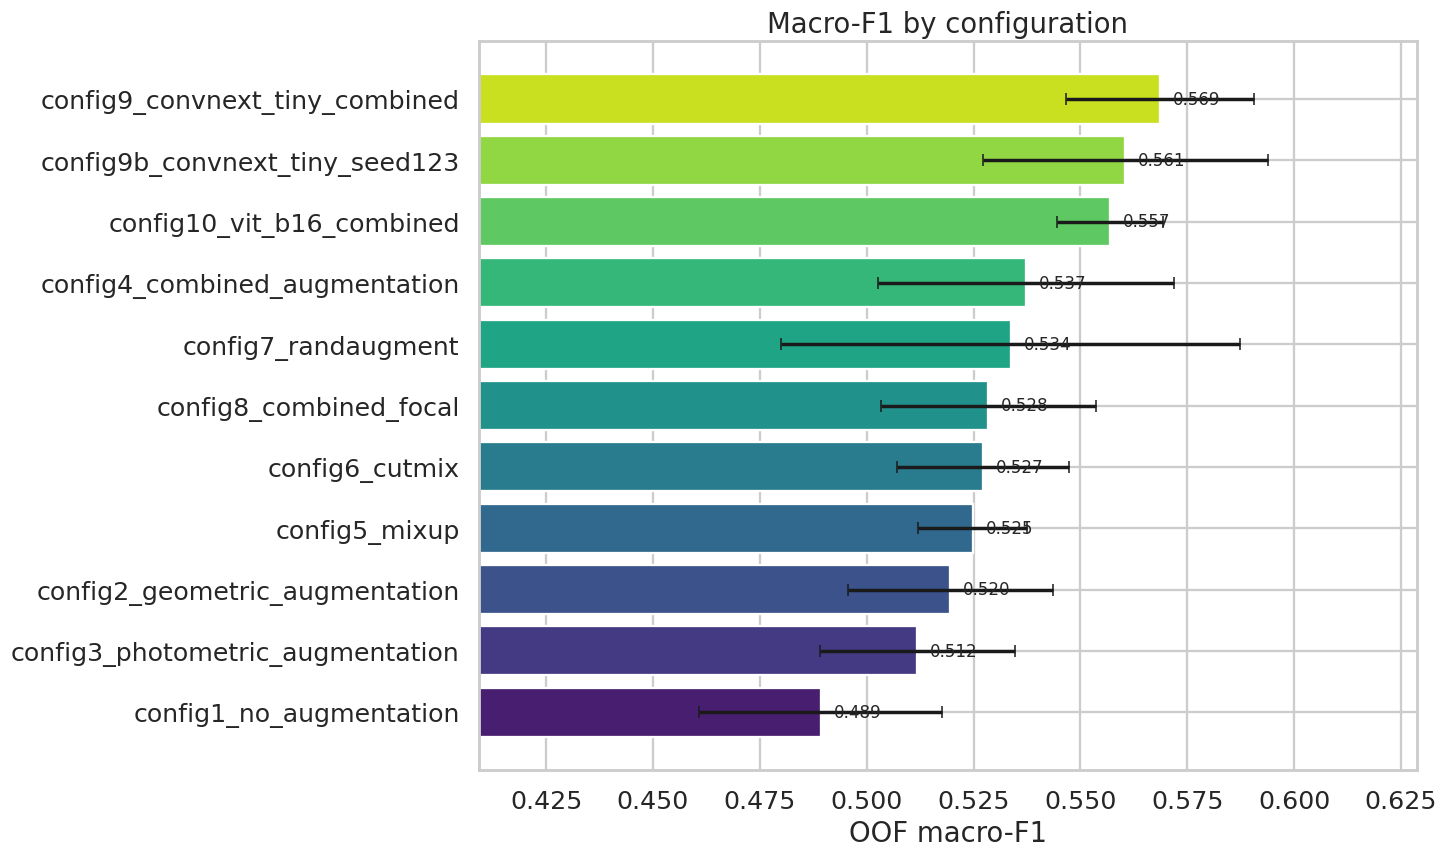

In [4]:
d = log.sort_values(COL["f1"], ascending=True)
fig, ax = plt.subplots(figsize=(11, 0.6 * len(d) + 2))
err = d[COL["std"]] if COL["std"] else None
colors = sns.color_palette("viridis", len(d))
ax.barh(d[COL["name"]], d[COL["f1"]], xerr=err, color=colors, capsize=4)
for i, v in enumerate(d[COL["f1"]]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=11)
ax.set_xlabel("OOF macro-F1")
ax.set_title("Macro-F1 by configuration")
ax.set_xlim(max(0, d[COL["f1"]].min() - 0.08), d[COL["f1"]].max() + 0.06)
plt.savefig("figures/macro_f1_by_config.png")
plt.show()

                        config_name  oof_accuracy  oof_macro_f1  OCA_recall
0           config1_no_augmentation      0.583000      0.489256    0.178295
1    config2_geometric_augmentation      0.588000      0.519547    0.279070
2  config3_photometric_augmentation      0.563333      0.511862    0.348837
3     config4_combined_augmentation      0.585000      0.537229    0.403101
4                     config5_mixup      0.584000      0.524798    0.348837
5                    config6_cutmix      0.594667      0.527266    0.294574
6               config7_randaugment      0.604333      0.533701    0.333333
7            config8_combined_focal      0.580667      0.528472    0.356589
8    config9_convnext_tiny_combined      0.614667      0.568662    0.441860
9         config10_vit_b16_combined      0.611333      0.556969    0.410853


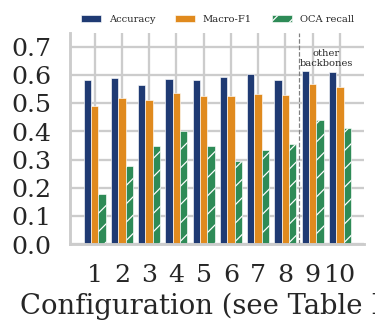

In [5]:
# Load every results_log.csv
files = sorted(NB_ROOT.glob("*/results/results_log.csv")) + sorted(VIT_DIR.rglob("results_log.csv"))
log = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
log = log.drop_duplicates(subset="config_name", keep="last")

# Config number and seed letter (config9b = seed 123, excluded)
log["num"] = log["config_name"].str.extract(r"config(\d+)", expand=False).astype(float)
log["suffix"] = log["config_name"].str.extract(r"config\d+([a-z]?)", expand=False)
log = log[(log["suffix"] == "") & log["num"].notna()]
log = log[~((log["num"] == 9) & (log["backbone"] == "resnet50"))]   # drop the bad duplicate row
d = log.sort_values("num").reset_index(drop=True)
print(d[["config_name", "oof_accuracy", "oof_macro_f1", "OCA_recall"]])   # check against Table IV

plt.rcParams.update({"font.family": "serif", "font.size": 7, "hatch.linewidth": 0.8})
x = d["num"].to_numpy()
w = 0.27
series = [
    ("oof_accuracy", "Accuracy",   "#1F3A73", None),
    ("oof_macro_f1", "Macro-F1",   "#E08A1E", None),
    ("OCA_recall",   "OCA recall", "#2E8B57", "//"),
]

fig, ax = plt.subplots(figsize=(3.45, 2.5))
for i, (col, label, color, hatch) in enumerate(series):
    ax.bar(x + (i - 1) * w, d[col], width=w, color=color, hatch=hatch,
           edgecolor="white", linewidth=0.4, label=label)

ax.axvline(8.5, color="gray", linestyle="--", linewidth=0.8)
ax.text(9.5, 0.66, "other\nbackbones", ha="center", va="center", fontsize=6.5)
ax.set_xticks(x)
ax.set_xticklabels([int(n) for n in x])
ax.set_xlabel("Configuration (see Table III)")
ax.set_ylim(0, 0.75)
ax.set_yticks(np.arange(0, 0.8, 0.1))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False, fontsize=6.5)

plt.savefig("fig1_metrics_by_config.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
oof_files  = sorted(NB_ROOT.glob("*/results/*oof*.csv"))
oof_files += sorted(VIT_DIR.rglob("*oof*.csv"))

oof = {}
for f in oof_files:
    df = pd.read_csv(f)
    t = pick(df, ["y_true", "true", "label", "target"])
    p = pick(df, ["y_pred", "pred", "prediction"])
    if not (t and p):
        print("skipped (no true/pred columns):", f.name)
        continue
    df = df.rename(columns={t: "y_true", p: "y_pred"})
    for c in ["y_true", "y_pred"]:
        if df[c].dtype == object:
            df[c] = df[c].map({n: i for i, n in enumerate(CLASS_NAMES)})
    oof[f.stem] = df

print(len(oof), "OOF files loaded:")
print(list(oof))

1 OOF files loaded:
['oof_predictions']


                           notebook  config  images
               03-baseline-pipeline       1    3000
  04-config2-geometric-augmentation       2    3000
05-config3-photometric-augmentation       3    3000
   06-config4-combined-augmentation       4    3000
                   07-config6-mixup       5    3000
                  08-config6-cutmix       6    3000
       09-config7-rand-augmentation       7    3000
image id column: None
{0: 8, 1: 7, 2: 17, 3: 6, 4: 9, 5: 12, 6: 24, 7: 46} | total OCA images: 129


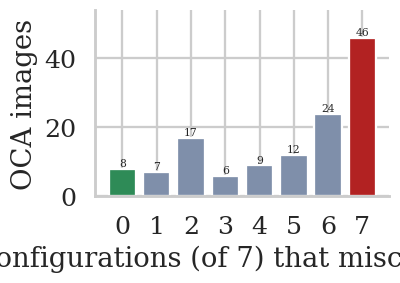

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

NB_ROOT = Path("/kaggle/input/notebooks/syedjaffarrazakazmi")
CLASS_NAMES = ["Healthy", "Benign", "OPMD", "OCA"]
OCA = 3

# notebook number prefix -> config number
NB_TO_CONFIG = {"03": 1, "04": 2, "05": 3, "06": 4, "07": 5, "08": 6, "09": 7}

def pick(df, options):
    for c in options:
        if c in df.columns:
            return c
    return None

by_num, rows = {}, []
for f in sorted(NB_ROOT.glob("*/results/*oof*.csv")):
    nb = f.parent.parent.name
    cfg = NB_TO_CONFIG.get(nb[:2])
    if cfg is None:
        continue
    df = pd.read_csv(f)
    t = pick(df, ["y_true", "true", "label", "target"])
    p = pick(df, ["y_pred", "pred", "prediction"])
    df = df.rename(columns={t: "y_true", p: "y_pred"})
    for c in ["y_true", "y_pred"]:
        if df[c].dtype == object:
            df[c] = df[c].map({n: i for i, n in enumerate(CLASS_NAMES)})
    by_num[cfg] = df
    rows.append({"notebook": nb, "config": cfg, "images": len(df)})

print(pd.DataFrame(rows).to_string(index=False))
assert sorted(by_num) == list(range(1, 8)), f"Missing configs: {sorted(set(range(1, 8)) - set(by_num))}"

id_col = pick(by_num[1], ["image_path", "image", "filename", "file", "path", "image_id", "id"])
print("image id column:", id_col)

truth = by_num[1]["y_true"].to_numpy()
miss = []
for k in range(1, 8):
    df = by_num[k]
    if id_col:
        df = df.set_index(id_col).reindex(by_num[1][id_col])
    assert (df["y_true"].to_numpy() == truth).all(), f"Row order or labels differ in config {k}"
    miss.append(df["y_pred"].to_numpy() != OCA)

miss = np.array(miss)
oca_mask = truth == OCA
n_wrong = miss[:, oca_mask].sum(axis=0)
counts = pd.Series(n_wrong).value_counts().reindex(range(8), fill_value=0)
print(counts.to_dict(), "| total OCA images:", counts.sum())   # paper: 8,7,17,6,9,12,24,46 and 129

colors = ["#2E8B57"] + ["#7F8FAA"] * 6 + ["#B22222"]
plt.rcParams.update({"font.family": "serif", "font.size": 7})
fig, ax = plt.subplots(figsize=(3.45, 2.2))
ax.bar(counts.index, counts.values, color=colors)
for i, v in zip(counts.index, counts.values):
    ax.text(i, v + 0.8, str(v), ha="center", fontsize=7)
ax.set_xticks(range(8))
ax.set_xlabel("Number of configurations (of 7) that misclassified the image")
ax.set_ylabel("OCA images")
ax.set_ylim(0, 54)
ax.spines[["top", "right"]].set_visible(False)

plt.savefig("fig2_oca_misclassification.png", dpi=300, bbox_inches="tight")
plt.show()

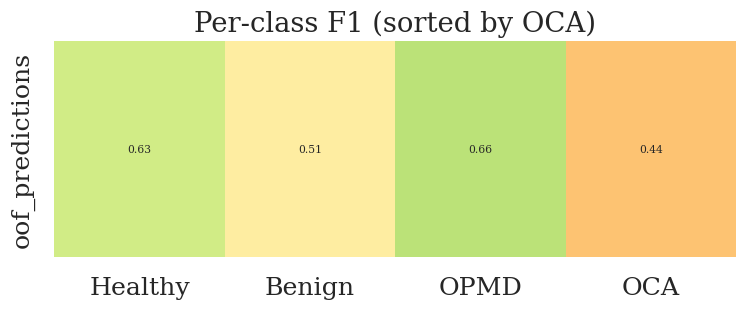

In [8]:
rows = {k: f1_score(v.y_true, v.y_pred, labels=range(4), average=None) for k, v in oof.items()}
pc = pd.DataFrame(rows, index=CLASS_NAMES).T.sort_values("OCA", ascending=False)

fig, ax = plt.subplots(figsize=(8, 0.55 * len(pc) + 2))
sns.heatmap(pc, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0.2, vmax=0.9, cbar=False, ax=ax)
ax.set_title("Per-class F1 (sorted by OCA)")
plt.savefig("figures/per_class_f1.png")
plt.show()

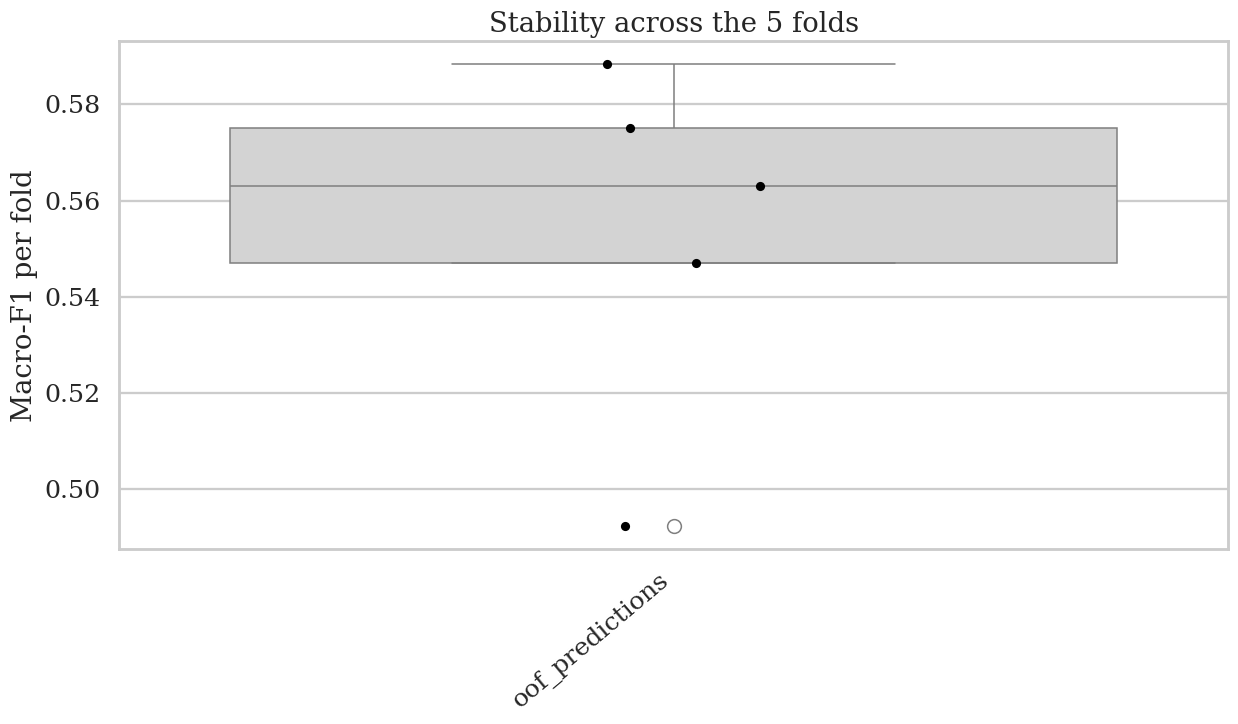

In [9]:
fold_rows = []
for k, v in oof.items():
    if "fold" in v.columns:
        for fo, g in v.groupby("fold"):
            fold_rows.append({"config": k, "fold": fo,
                              "macro_f1": f1_score(g.y_true, g.y_pred, average="macro")})
if fold_rows:
    fd = pd.DataFrame(fold_rows)
    order = fd.groupby("config").macro_f1.median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.boxplot(data=fd, x="config", y="macro_f1", order=order, color="lightgray", ax=ax)
    sns.stripplot(data=fd, x="config", y="macro_f1", order=order, color="black", size=6, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("Macro-F1 per fold")
    ax.set_title("Stability across the 5 folds")
    plt.xticks(rotation=40, ha="right")
    plt.savefig("figures/fold_stability.png")
    plt.show()
else:
    print("No 'fold' column in the OOF files, skipping this plot.")

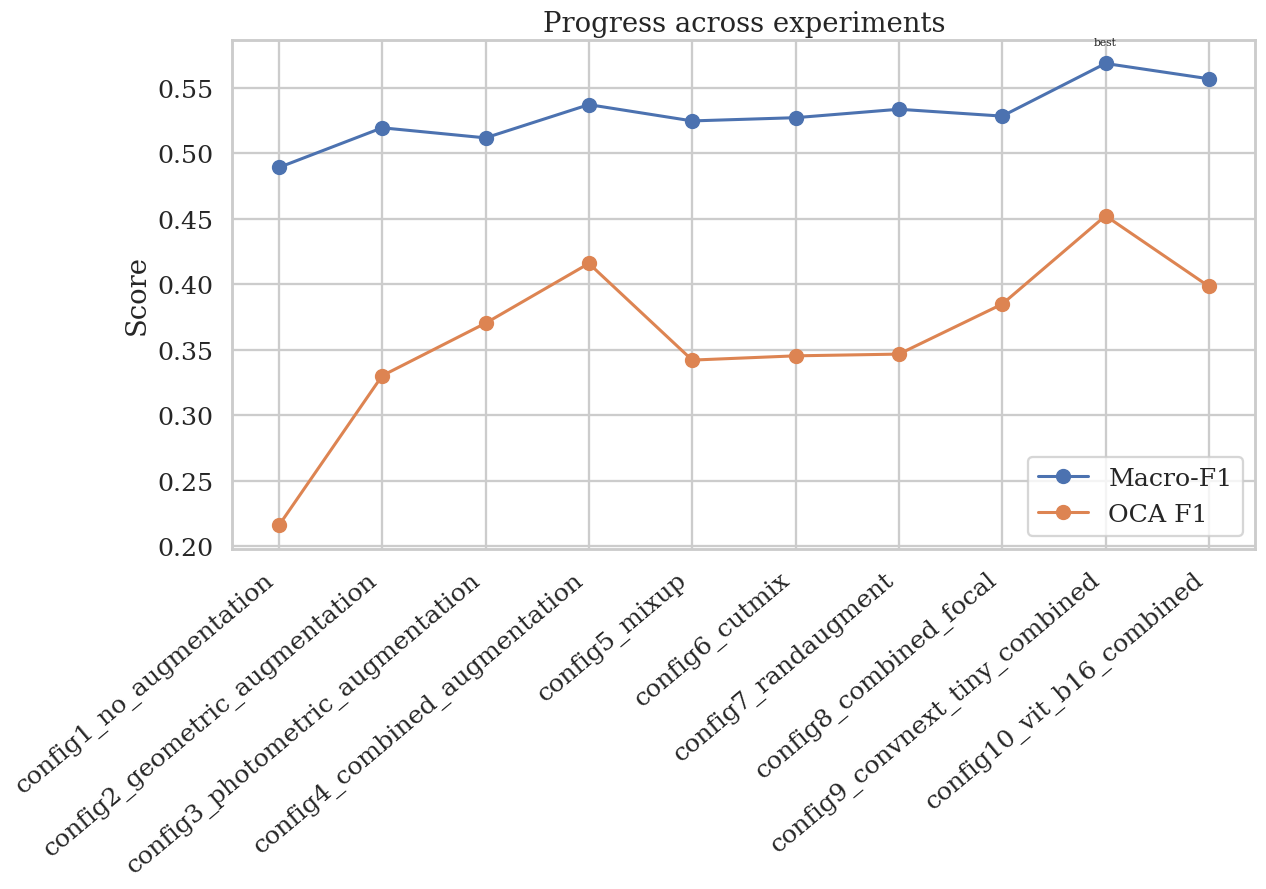

In [10]:
import re
p = log.copy()
p["order"] = p[COL["name"]].str.extract(r"config(\d+)").astype(float)
p = p.sort_values("order")

fig, ax = plt.subplots(figsize=(12, 6))
for key, label in [("f1", "Macro-F1"), ("oca_f1", "OCA F1")]:
    if COL[key]:
        ax.plot(p[COL["name"]], p[COL[key]], marker="o", linewidth=2, label=label)
best = p.loc[p[COL["f1"]].idxmax()]
ax.annotate("best", (best[COL["name"]], best[COL["f1"]]),
            textcoords="offset points", xytext=(0, 12), ha="center")
ax.set_ylabel("Score")
ax.set_title("Progress across experiments")
plt.xticks(rotation=40, ha="right")
ax.legend()
plt.savefig("figures/progress_line.png")
plt.show()

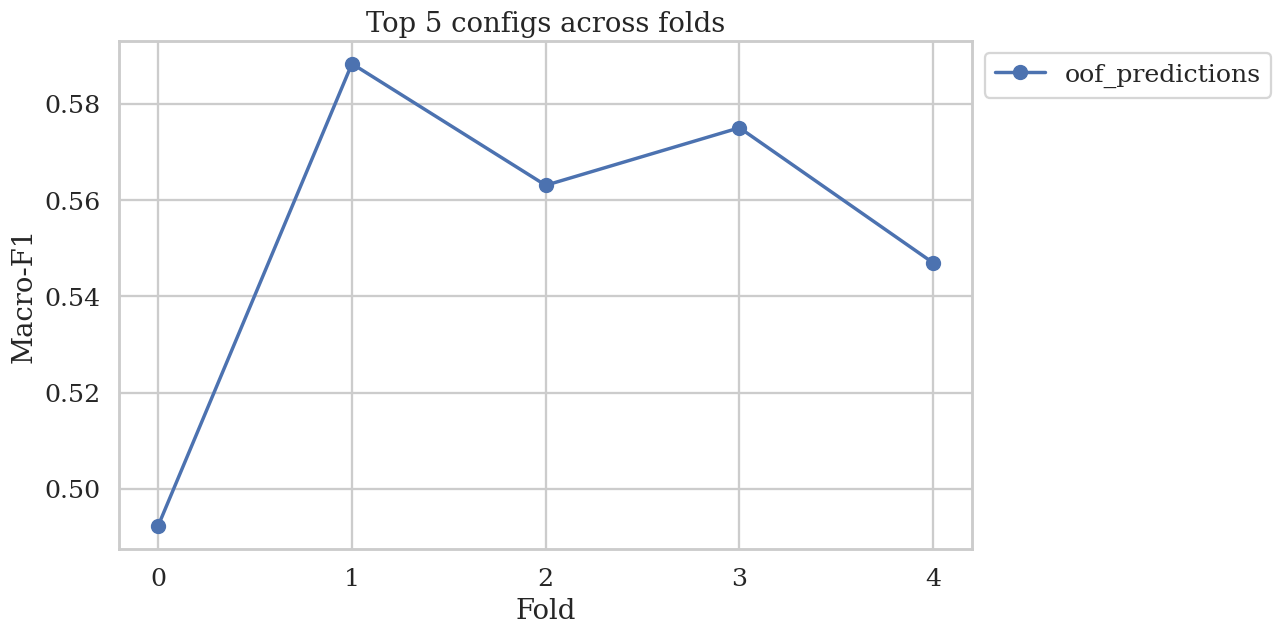

In [11]:
if fold_rows:
    fd = pd.DataFrame(fold_rows)
    top_cfgs = sorted(oof, key=lambda k: f1_score(oof[k].y_true, oof[k].y_pred, average="macro"),
                      reverse=True)[:5]
    fig, ax = plt.subplots(figsize=(10, 6))
    for k in top_cfgs:
        g = fd[fd.config == k].sort_values("fold")
        ax.plot(g.fold, g.macro_f1, marker="o", label=k)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Macro-F1")
    ax.set_xticks(range(5))
    ax.set_title("Top 5 configs across folds")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.savefig("figures/fold_lines.png")
    plt.show()